In [1]:
%load_ext autoreload
    
%autoreload 2
%matplotlib inline

In [2]:
import os
from random import sample
import re
import time
import copy as cp
import argparse
import toml
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import pandas as pd
import zeus

from matplotlib.ticker import LinearLocator, MultipleLocator, AutoMinorLocator, MaxNLocator
from scipy.interpolate import PchipInterpolator, CubicSpline, interp1d

import alfred.utils as utils
import alfred.emulator as emulator
import alfred.KSZ as KSZ
import alfred.peefit as peefit
import alfred.surveys as surveys

import joblib
import keras
import tensorflow as tf

tf.config.set_visible_devices([], "GPU")

import warnings
from types import SimpleNamespace
from scipy.interpolate import RegularGridInterpolator, RectBivariateSpline
from catwoman.shelter import Cat

import alfred.surveys as surveys
import alfred.emulator as emulator
import alfred.utils as utils
from alfred.parameters import *
from alfred.astrofit import *



2025-11-12 14:52:52.147452: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762955572.970393 2127790 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762955573.190097 2127790 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1762955574.839291 2127790 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1762955574.839349 2127790 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1762955574.839352 2127790 computation_placer.cc:177] computation placer alr

parsing /data/cluster/emc-brid/Datasets/LoReLi/spectra/kSZ/LoReLi/nells30_v5 ...
6797 sims available
Now on 0 run...
Now on 1 run...
Now on 2 run...
Now on 3 run...
Now on 4 run...


In [6]:
priors_samples = np.load(
    f"{base_dir}/inference/productionruns7_addhksz/samples_addtauCMB/samples_priors_hypercube.npy"
)
prior_samples = make_tauchains(
    priors_samples[:, :3],
    A=False,
    dropA=False,
    truths=df.loc[config.sn].to_dict(),
)

prior_samples[:,0] += - np.log10(1e2)

nbins = 30
prior_hists = [np.histogram(row, bins=30, density=True) for row in prior_samples.T]

/home/emc-brid/alfred/src/alfred/keras_xe_emul.py:172: RuntimeWarning: divide by zero encountered in log10
  np.log10(zvect),


In [7]:
raw_samples, _ = utils.load_samples(f"{base_dir}/inference/productionruns7_addhksz/CMB-HD/noiseless")
# samples = make_tauchains(
#     raw_samples[:, :3],
#     A=False,
#     dropA=False,
#     truths=df.loc[config.sn].to_dict(),
# )

Loading samples from /data/cluster/emc-brid/Datasets/LoReLi/inference/productionruns7_addhksz/CMB-HD/noiseless...


In [11]:
fidmeans, fidbiases, fidsigmas = summary_statistics(raw_samples, config.sn, prior_hists, verbose=True)

samples: [1.3237394  8.48005296 0.25793423 0.05313289]
truths: [np.float64(-1.7166987712964503), np.float64(0.0), np.float64(1.277127671229863), np.float64(8.53), np.float64(0.275), np.float64(0.05513605350367262)]
means: [1.27567658 8.47992494 0.25796815 0.05334431]
low68: [1.12853144 8.16899624 0.22517319 0.05159486]
high68: [1.42197307 8.78428762 0.29024867 0.05509785]
biases are: [-0.00145109 -0.05007506 -0.01703185 -0.00179174]
sigmas are: [0.14714513 0.3109287  0.03279496 0.00175354]


In [13]:
for i in range(len(fidmeans)):
    print(f"{fidmeans[i]:.4f} +/- {fidsigmas[i]:4f}")

1.2757 +/- 0.147145
8.4799 +/- 0.310929
0.2580 +/- 0.032795
0.0533 +/- 0.001754


In [14]:
nb_fid = fidbiases / fidsigmas
nb_fid

array([-0.00986166, -0.16104997, -0.51934344, -1.02178385])

In [29]:
truths = np.load(f"{base_dir}/metadata/batchstats_v2/truths_v2.npy")
means = np.load(f"{base_dir}/metadata/batchstats_v2/means_weighted_v2.npy")
medians = np.load(f"{base_dir}/metadata/batchstats_v2/medians_v2.npy")

compmeans = np.load(f"{base_dir}/metadata/batchstats_v2/means_v2.npy")
complow68 = np.load(f"{base_dir}/metadata/batchstats_v2/low68_v2.npy")
comphigh68 = np.load(f"{base_dir}/metadata/batchstats_v2/high68_v2.npy")

low68 = np.load(f"{base_dir}/metadata/batchstats_v2/low68_weighted_v2.npy")
high68 = np.load(f"{base_dir}/metadata/batchstats_v2/high68_weighted_v2.npy")

low95 = np.load(f"{base_dir}/metadata/batchstats_v2/low95_weighted_v2.npy")
high95 = np.load(f"{base_dir}/metadata/batchstats_v2/high95_weighted_v2.npy")

edges68 = []
edges95 = []

def summary_statistics(means, truths, low68, high68):
    edges68 = []
    for i in range(means.shape[0]):
        low = low68[i]
        high = high68[i]
    
        edges68.append((low, high))

    if means.ndim == 1:
        intervals68 = edges68 - np.stack([means, means], axis=1)
        biases = (means - truths[2:])
        print(np.abs(intervals68))
        sigma_max_68 = np.max(np.abs(intervals68), axis=1)
    else:
        intervals68 = edges68 - np.stack([means, means], axis=1)
        intervals68 = np.swapaxes(intervals68, 1, 2)
    # for i in range(means.shape[0]):
    #     low = low95[i]
    #     high = high95[i]
        
    #     edges95.append((low, high))
    
    # intervals95 = edges95 - np.stack([means, means], axis=1)
    # intervals95 = np.swapaxes(intervals95, 1, 2)

        biases = (means - truths[:,2:])
        sigma_max_68 = np.max(np.abs(intervals68), axis=2)

    return biases, sigma_max_68

biases, sigma = summary_statistics(means, truths, low68, high68)

In [31]:
biases[:-19].shape, biases.mean(axis=0)

((1000, 4), array([ 0.00055361, -0.04286645, -0.00831533, -0.00037009]))

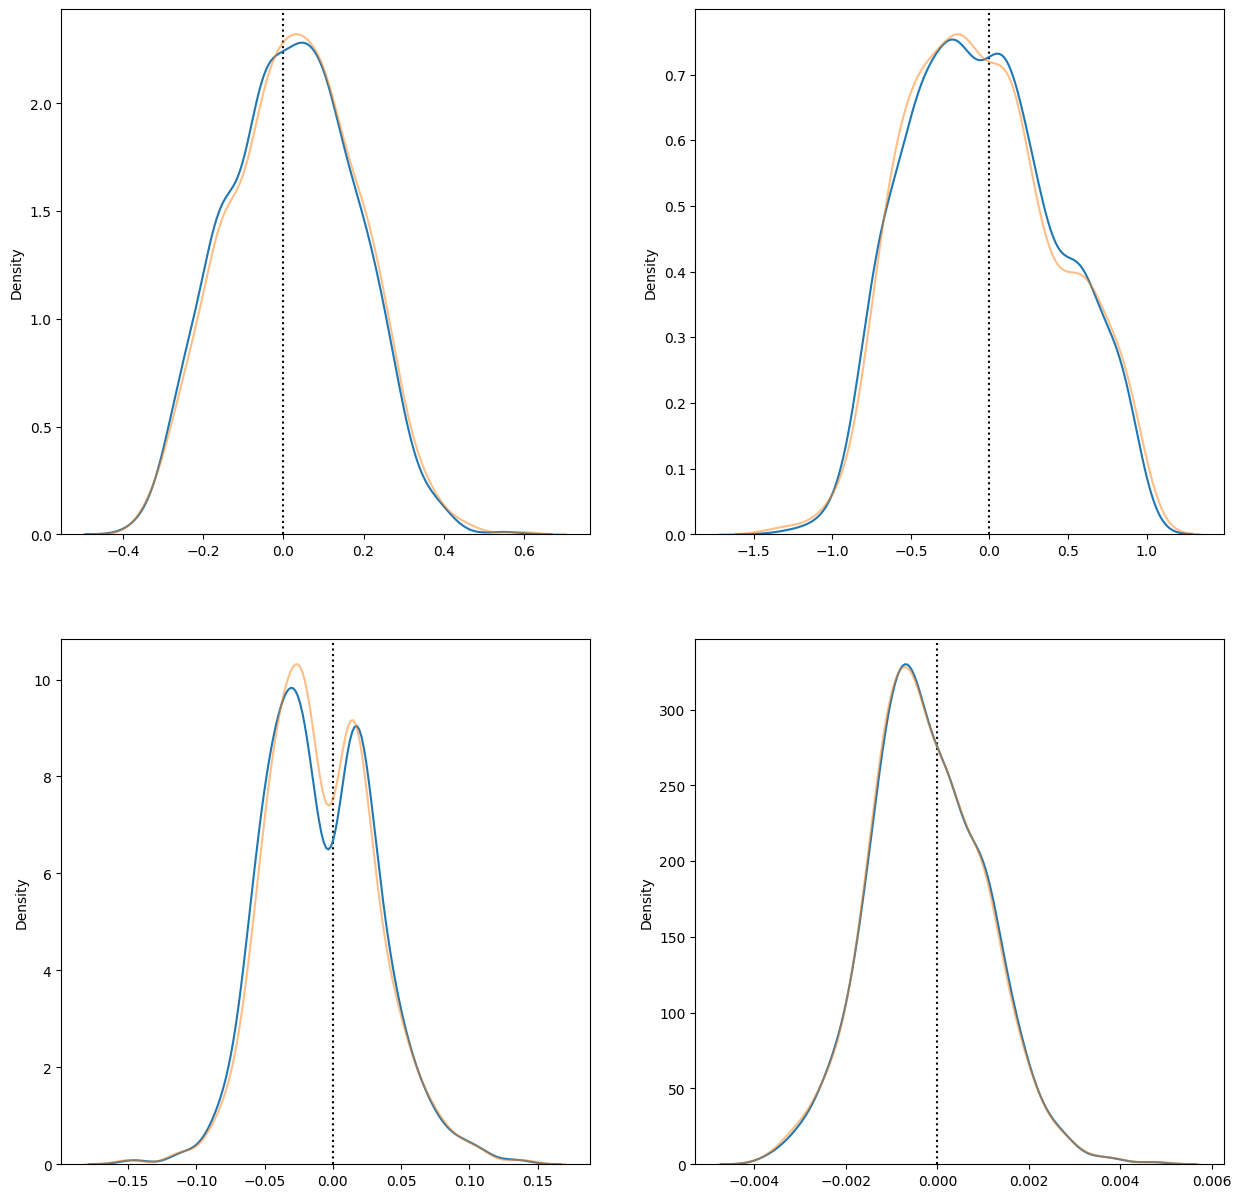

In [17]:
fig, ax = plt.subplots(2,2,figsize=(15, 15))

ax = ax.flatten()

[a.axvline(0.0, color='black', ls=':') for a in ax]

for i in range(4):
    sns.kdeplot(compmeans[:,i] - truths[:,2+i], ax=ax[i])
    sns.kdeplot(medians[:,i] - truths[:,2+i], alpha=.5, ax=ax[i])
# plt.hist(compmeans - truths)

In [18]:
stats_labels = ['sims', 'truths', 'ravg', 'medians', 'low68', 'high68', 'low95', 'high95', 'intervals68', 'intervals95']

In [19]:
plt.rcParams.update({
    "text.usetex": True,  # Use LaTeX for rendering
    'font.size': 13,
    "font.family": "serif",  # Use serif font
    "font.serif": ["Computer Modern Roman"],  # LaTeX's default font
})

In [20]:
prior_CI = get_ci(priors_samples[:,:3], config.sn, ci=68, edges=False)

/home/emc-brid/alfred/src/alfred/keras_xe_emul.py:172: RuntimeWarning: divide by zero encountered in log10
  np.log10(zvect),


<>:32: SyntaxWarning: invalid escape sequence '\-'
<>:32: SyntaxWarning: invalid escape sequence '\-'
/tmp/ipykernel_2127790/2515441486.py:32: SyntaxWarning: invalid escape sequence '\-'
  print(f"CI coverage {np.mean(CI)/prior_CI[i]:.5f} +\- {np.std(CI)/prior_CI[i]:.5f}")


For parameter $\tau_{\mathrm{SF}}$, mean=0.14205 and sigma=0.05532
CI coverage 0.56373 +\- 0.21953
For parameter $\log{M_{\mathrm{min}}}$, mean=0.42866 and sigma=0.13840
CI coverage 0.78969 +\- 0.25496
For parameter $f_{\mathrm{esc}}$, mean=0.02691 and sigma=0.00978
CI coverage 0.17580 +\- 0.06387
For parameter $\tau_{\mathrm{CMB}}$, mean=0.00130 and sigma=0.00026
CI coverage 0.17355 +\- 0.03476


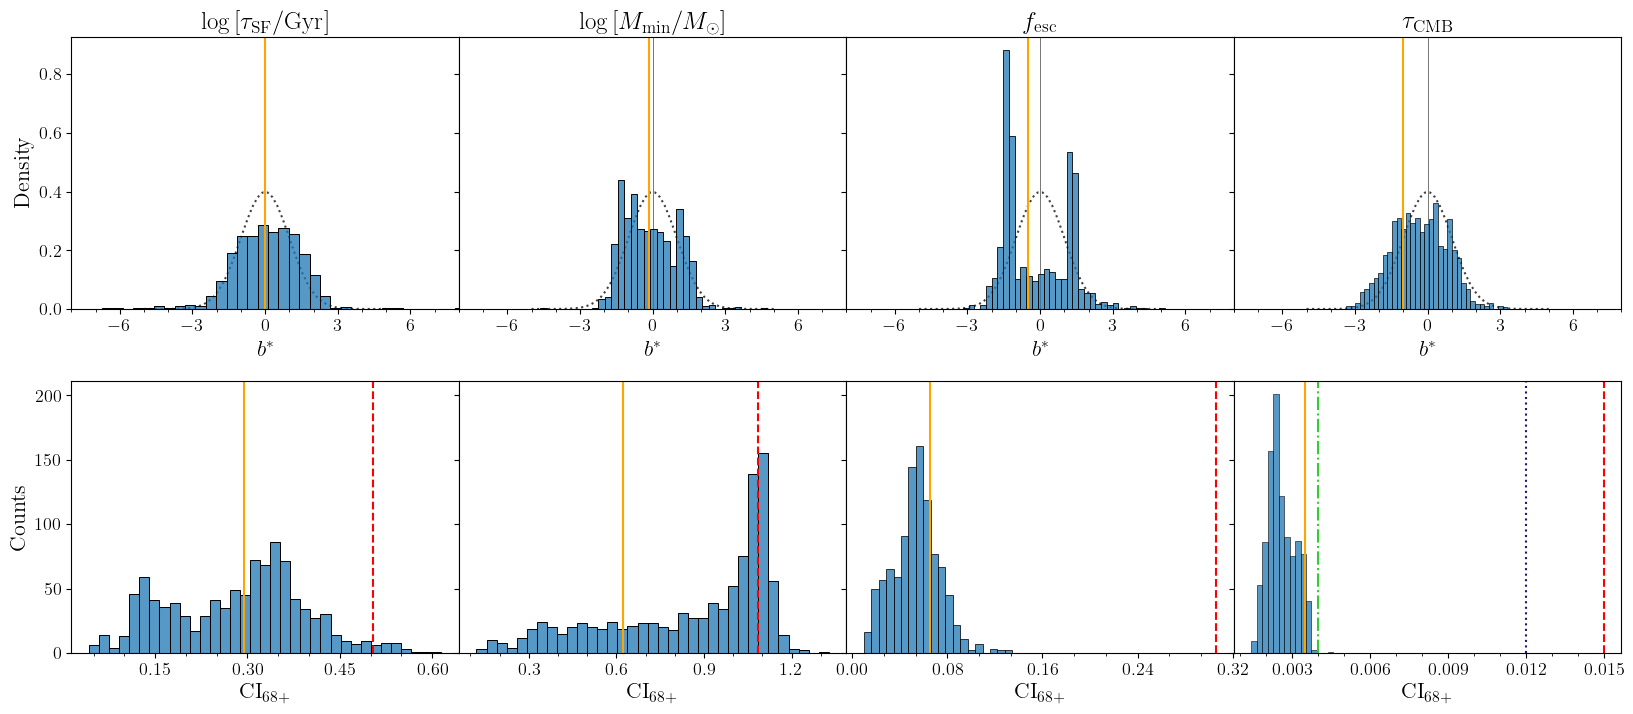

In [32]:
fig, ax = plt.subplots(2,4, sharex=False, sharey='row', figsize=(20,8))
fig.subplots_adjust(wspace=0.0, hspace=.265)

[ax[0,i].axvline(0.0, color='black', alpha=.75, lw=.5, ls='-', zorder=0) for i in range(4)]
# [ax[1,i].axvline(1.0, color='black', alpha=.5) for i in range(4)]

for i, pname in enumerate(astro_wunits[2:-2]):
    nbins = 35
    ax[0,i].set_title(pname, fontsize=18)

    ax[0,i].axvline(nb_fid[i], color='orange')

    nb = biases[:-19,i] / sigma[:-19,i]

    x = np.linspace(-5,5)
    ax[0,i].plot(x, np.exp(-.5 * x**2) / np.sqrt(2.0 * np.pi), color='black', alpha=.75, ls=':', zorder=0)


 #   sns.histplot(np.random.normal(size=len(nb)), ax=ax[0,i], stat='density', bins=bins, alpha=.25, color='black')
    sns.histplot(nb, ax=ax[0,i], bins=nbins, stat='density', alpha=.75)
    
    

    # counts, bin_edges, patches = ax[1,i].hist(2 * sigma_max_68[:,i],
    #                                   bins=bins, density=True, alpha=1.0)

    CI = 2 * sigma[:-19,i]  
    ax[1,i].axvline(2 * fidsigmas[i], color='orange')
    ax[1,i].axvline(prior_CI[i], color='red', ls='--') 

    print(f"For parameter {astro_pnames_formatted[2+i]}, mean={np.mean(sigma[:-19,i]):.5f} and sigma={np.std(sigma[:-19,i]):.5f}")
    print(f"CI coverage {np.mean(CI)/prior_CI[i]:.5f} +\- {np.std(CI)/prior_CI[i]:.5f}")

    if i ==2:
        nbins = 20
    if i ==3:
        nbins = 15
    if i == 3:
        ax[1,i].axvline(2 * .006, color=colors[4], ls=':')
        ax[1,i].axvline(2 * 0.002, color='limegreen', ls='dashdot')
    sns.histplot(CI, ax=ax[1,i], bins=nbins, alpha=.75)

    ax[0,i].set_ylabel('')
    ax[1,i].set_ylabel('')

    ax[0,i].xaxis.set_major_locator(MultipleLocator(3.0))
    ax[0,i].xaxis.set_minor_locator(MultipleLocator(1.0))

    ax[1,i].xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax[1,i].xaxis.set_minor_locator(AutoMinorLocator(3))
    
#     # Split patches into filled and unfilled groups
#     split = 26 # higher than this is 1.0
    
#     # Make the first half filled (with color)
#     for j in range(split):
#         patches[j].set_facecolor(sns.color_palette()[0])
#         patches[j].set_edgecolor(darker)
    
#     # Make the second half unfilled (just borders)
#     for j in range(split, len(patches)):
#         patches[j].set_facecolor('none')
#         patches[j].set_edgecolor(sns.color_palette()[0])

#     # sns.histplot(2 * np.max(np.abs(stats_v2['intervals95']), axis=2)[:,i] / widths[i], stat='density', bins=bins, ax=ax[1,i])
#     mean_CI = 2 * np.mean(np.max(np.abs(stats_v2['intervals95']), axis=2)[:,i] / widths[i])
#     std_CI = 2 * np.std(np.max(np.abs(stats_v2['intervals95']), axis=2)[:,i] / widths[i])
#     ax[1,i].axvline(mean_CI, color=darker)
#     ax[1,i].axvspan(mean_CI - std_CI, mean_CI + std_CI, color=darker, alpha=.15)
# #    ax[1,i].axvspan(1.0, 1.75, color='black', hatch='//', fill=False, alpha=.5, zorder=0)
#     ax[1,i].axvline(fidCI[i] / widths[i], color=sns.color_palette()[1])
#     if i == 3:
#         ax[1,i].axvline((2 * .006) / widths[i], color=sns.color_palette()[2], ls=(0, (5, 1)), lw=.9, alpha=.9)

#     print(f"\t mean_CI={mean_CI:.3f}, std_CI={std_CI:3f}") 
#     print()

[ax[0,i].set_xlabel(r"$b^*$", fontsize=16) for i in range(4)]
[ax[1,i].set_xlabel(r"$\mathrm{CI}_{68+}$", fontsize=16) for i in range(4)]

# ax[0,0].set_ylabel(r"$\hat{p}(\theta)$", fontsize=16)
ax[0,0].set_ylabel(r"Density", fontsize=16)
ax[1,0].set_ylabel(r"Counts", fontsize=16)


[ax[0,i].set_xlim(-8,8) for i in range(4)]
# [ax[0,i].set_ylim(0.0,.95) for i in range(4)]

# [ax[1,i].set_ylim(0.0,225) for i in range(4)]

fig.savefig('biases.pdf', bbox_inches='tight', pad_inches=0.05, dpi=300)

In [50]:
np.mean(np.abs(biases[:-19] / sigma[:-19]) > 1, axis=0)

array([0.466, 0.456, 0.765, 0.425])

In [44]:
priors[2] - np.log10(1e2)

array([0.86858567, 2.02138365])

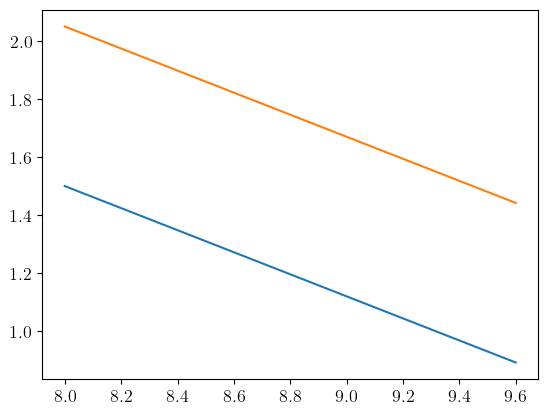

In [36]:
x = np.linspace(*priors[3])

plt.plot(x, -.38 * x + 6.54 - 2)
plt.plot(x, -.38 * x + 7.09 - 2)

In [81]:
sigma.mean(axis=0), sigma.var(axis=0)

(array([0.14283224, 0.43119846, 0.02696489, 0.00120741]),
 array([3.04336516e-03, 1.87014222e-02, 9.45131417e-05, 5.84424840e-08]))

In [94]:
for s in sigma.var(axis=0):
    print(f"{s:.5f}")

0.00304
0.01870
0.00009
0.00000


In [ ]:
fig, ax = plt.subplots(4,2, sharex=False, sharey=False, figsize=(5,15))
fig.subplots_adjust(wspace=0.0, hspace=.265)

[ax[i,0].axvline(0.0, color='black', alpha=.25, lw=.5, ls='-', zorder=0) for i in range(4)]
# [ax[1,i].axvline(1.0, color='black', alpha=.5) for i in range(4)]

bins = 30

for i, pname in enumerate(astro_pnames_formatted[2:-1]):
    ax[i,0].set_ylabel(pname, fontsize=18)

    nb = biases[:,i] / sigma_max_68[:,i]

    sns.histplot(nb, ax=ax[i,0], label=None, alpha=.75)

    # counts, bin_edges, patches = ax[1,i].hist(2 * sigma_max_68[:,i],
    #                                   bins=bins, density=True, alpha=1.0)

    sns.histplot(2 * sigma_max_68[:,i], ax=ax[i,1], alpha=.75)
    

# [ax[i,0].set_xlabel(r"$b^*$", fontsize=16) for i in range(4)]

# [ax[i,1].set_xlabel(r"$\mathrm{CI}_{68+}$", fontsize=16) for i in range(4)]

# [ax[i,0].set_ylabel("", fontsize=16) for i in range(4)]
[ax[i,1].set_ylabel("", fontsize=16) for i in range(4)]

# ax[0,0].xaxis.set_major_locator(MultipleLocator(1.0))
# ax[0,0].xaxis.set_minor_locator(MultipleLocator(0.5))

ax[0,0].set_xlim(-2.95,2.95)

fig.savefig('biases.pdf', bbox_inches='tight', pad_inches=0.05, dpi=300)

In [ ]:
fig, axs = plt.subplots(10,4, sharex='col', sharey=True, figsize=(10,30))
fig.subplots_adjust(hspace=0.0)

for i in range(10):
    ax = axs[i]
    truth = truths[i]
    mean = means[i]
    low68_i = low68[i]
    high68_i = high68[i]
    sigma = sigma_max_68[i]

    for j in range(4):
        t = truth[2+j]
        m = mean[j]
        l = low68_i[j]
        h = high68_i[j]
        s = sigma[j]

        # print(t)
        ax[j].axvline(t, color='black')
        ax[j].axvline(m, color='red')
        ax[j].axvline(l, color='red', ls=':')
        ax[j].axvline(h, color='red', ls=':')
        ax[j].axvspan(m - s, m + s, color='blue', alpha=.1)
